Choose function: 1 = e^x, 2 = 1/(1+x^2):  2


Selected: f(x) = 1/(1+x^2)
Interpolation nodes: [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5]

Interpolation polynomial:
-2.26244343891403e-5*x**10 + 8.470329472543e-21*x**9 + 0.00126696832579186*x**8 - 5.42101086242752e-19*x**7 - 0.0244117647058824*x**6 + 8.67361737988404e-18*x**5 + 0.19737556561086*x**4 - 6.24500451351651e-17*x**3 - 0.67420814479638*x**2 + 1.17961196366423e-16*x + 1.0


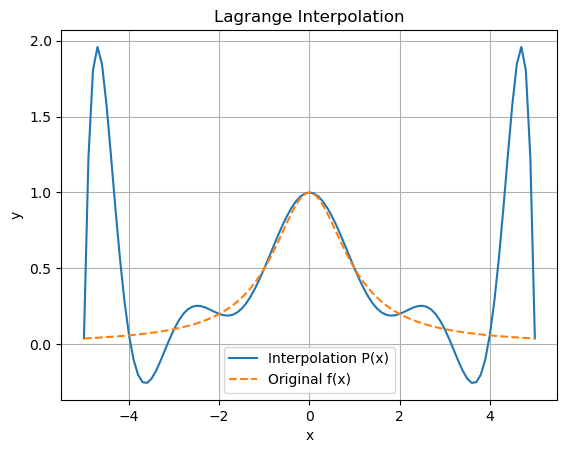

In [2]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

x = sp.symbols('x')

# ---- choose function ----
choice = int(input("Choose function: 1 = e^x, 2 = 1/(1+x^2): "))

if choice == 1:
    def f(x):
        return sp.exp(x)
    L = [-1, 0.5, 1.5, 2]
    print("Selected: f(x) = e^x")
    print("Interpolation nodes:", L)

elif choice == 2:
    def f(x):
        return 1 / (1 + x**2)
    L = list(range(-5, 6))  # [-5, -4, ..., 5]
    print("Selected: f(x) = 1/(1+x^2)")
    print("Interpolation nodes:", L)

else:
    print("Invalid choice")
    exit()

m = len(L)

# ---- Lagrange interpolation ----
P = 0

for j in range(m):
    Lj = 1
    for i in range(m):
        if i != j:
            Lj *= (x - L[i]) / (L[j] - L[i])
    P += Lj * f(L[j])

P = sp.simplify(P)

print("\nInterpolation polynomial:")
print(P)

# ---- convert to numerical functions ----
P_func = sp.lambdify(x, P, 'numpy')

if choice == 1:
    f_num = lambda x: np.exp(x)
else:
    f_num = lambda x: 1 / (1 + x**2)

# ---- generate x values ----
x_vals = np.arange(-5, 5.1, 0.1)

# ---- compute values ----
P_vals = P_func(x_vals)
f_vals = f_num(x_vals)

# ---- plot ----
plt.plot(x_vals, P_vals, label="Interpolation P(x)")
plt.plot(x_vals, f_vals, label="Original f(x)", linestyle='--')

plt.legend()
plt.title("Lagrange Interpolation")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()

plt.show()